In [1]:
import shap
print(shap.__version__)

0.52.0


In [2]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [4]:
model = joblib.load("../models/xgboost_tuned.pkl")

In [5]:
X_test = pd.read_csv("../data/processed/X_test.csv")

In [6]:
explainer = shap.TreeExplainer(model)

In [7]:
sample = X_test.sample(1000, random_state=42)

shap_values = explainer.shap_values(sample)

In [8]:
sample = X_test.sample(1000, random_state=42)

shap_values = explainer.shap_values(sample)

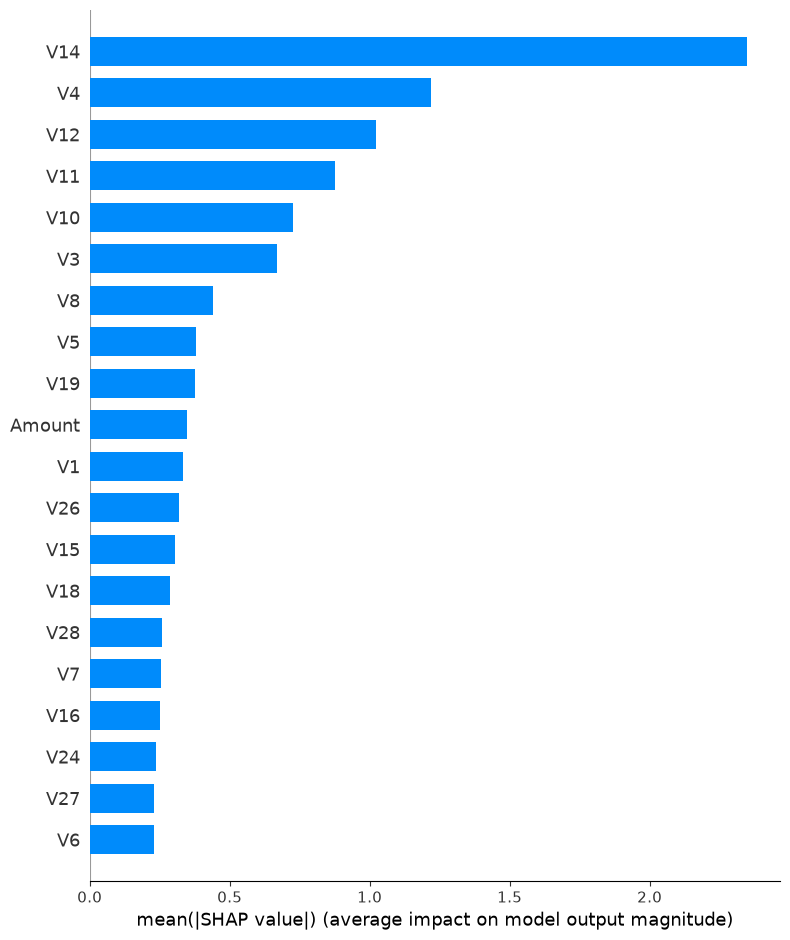

In [9]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

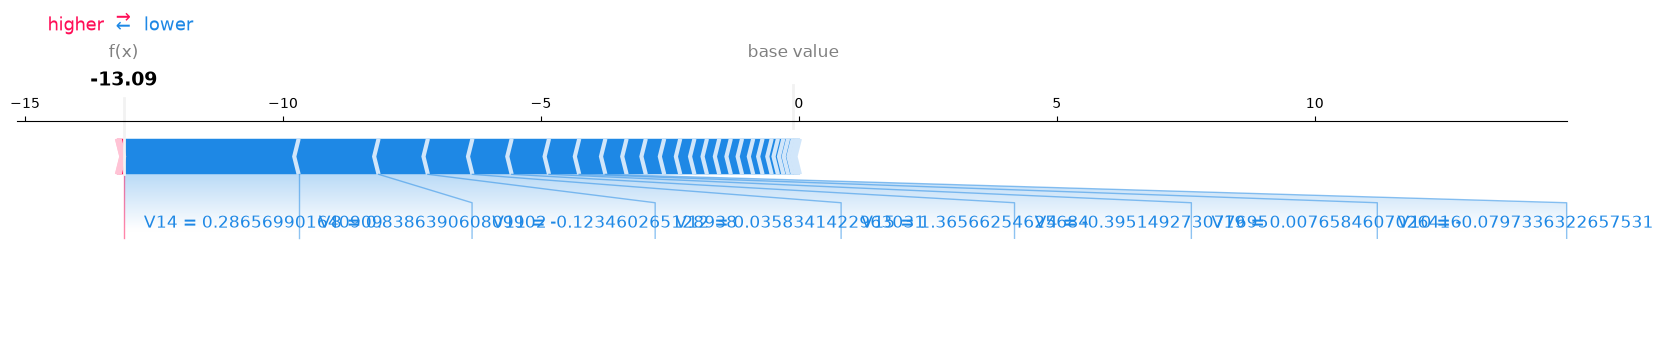

In [10]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample.iloc[0],
    matplotlib=True
)

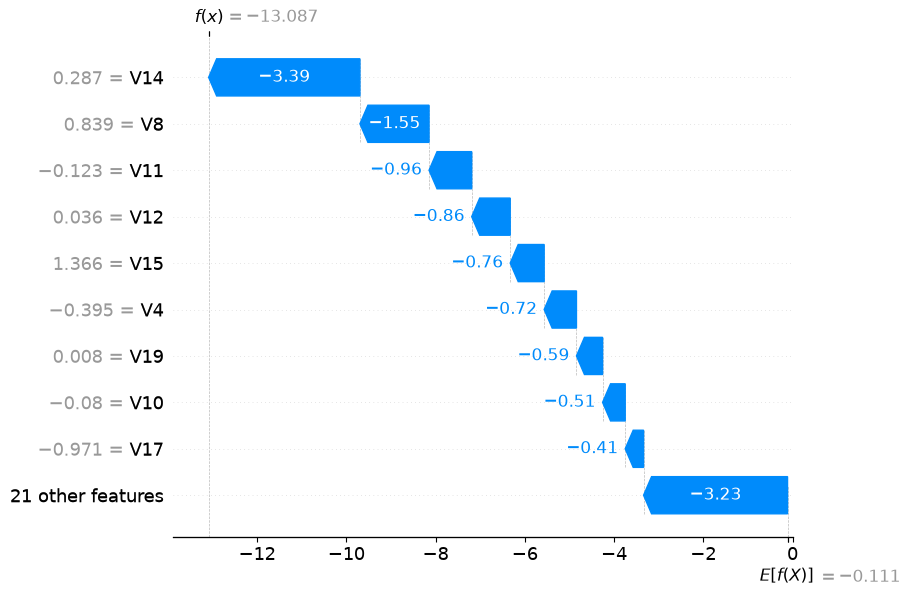

In [11]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

In [12]:
importance = pd.DataFrame({
    "Feature": sample.columns,
    "Importance": abs(shap_values).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
14,V14,2.348040
4,V4,1.218256
12,V12,1.022403
11,V11,0.875184
10,V10,0.725936
3,V3,0.668346
8,V8,0.439396
5,V5,0.378320
19,V19,0.376287
29,Amount,0.347236


In [13]:
importance.to_csv(
    "../models/shap_feature_importance.csv",
    index=False
)

## Conclusion

SHAP improves the interpretability of the fraud detection model by identifying how each feature contributes to individual predictions.

This increases transparency and helps build trust in model decisions, which is especially important in financial applications where predictions may require explanation.